<>:193: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:195: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:193: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:195: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_1401/1761756072.py:193: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.xlabel(f'$\gamma_2$', fontsize=12)
/var/folders/w5/_xj_10752qq46lvtdj31knl40000gn/T/ipykernel_1401/1761756072.py:195: SyntaxWarning: "\p" is an 

-----------------------------------
Duration of the evolution t = 600
interval (evolution time step) = 0.005
-----------------------------------
In this code we make no measurement! Just COHERENT unitary evolution
-----------------------------------
Parameters initialized!
State at time = 0 initialized! Using N = 20, gamma_2 = 0.0
State at time = 0 initialized! Using N = 20, gamma_2 = 0.0012515644555694619
State at time = 0 initialized! Using N = 20, gamma_2 = 0.0025031289111389237
State at time = 0 initialized! Using N = 20, gamma_2 = 0.003754693366708386
State at time = 0 initialized! Using N = 20, gamma_2 = 0.0050062578222778474
State at time = 0 initialized! Using N = 20, gamma_2 = 0.006257822277847309
State at time = 0 initialized! Using N = 20, gamma_2 = 0.007509386733416772
State at time = 0 initialized! Using N = 20, gamma_2 = 0.008760951188986232
State at time = 0 initialized! Using N = 20, gamma_2 = 0.010012515644555695
State at time = 0 initialized! Using N = 20, gamma_2 = 0

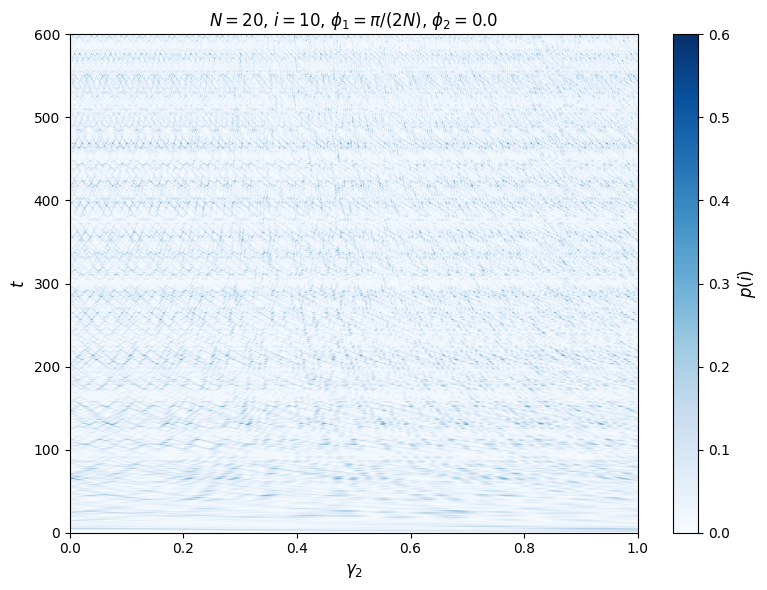

In [1]:
import numpy as np # for doing stuff with numbers
import matplotlib.pyplot as plt # for plotting
from scipy.linalg import expm # this we need for the time evolution operator
import pandas as pd # to easily print matrices


########################################## PROJECTIVE MEASUREMENT FUNCTION (PVM)

import random
random.seed(13) # for reproducibility

def on_site_PVM(state, target_site):

    # prepare probability to extract outcome and 'blank' state to write the result
    prob_success = np.abs(state[target_site]) ** 2 # this is |<i|psi>|^2
    collapsed_state = np.zeros_like(state) # that is, np.zeros(len(psi), dtype=psi.dtype)
    detection_successful = False

    if (random.random()>=prob_success):
        # print(f"Walker is NOT at site {target_site}.")
        # projecting on the complementary subspace
        collapsed_state = state.copy()
        collapsed_state[target_site] = 0.0 
        # renormalize
        norm = np.linalg.norm(collapsed_state)
        if norm > 0:
            collapsed_state = collapsed_state/norm
    else:
        print(f"Success! Walker at site {target_site}.")
        collapsed_state[target_site] = state[target_site] / np.sqrt(prob_success)
        detection_successful = True

    return collapsed_state, detection_successful


########################################## FUNCTION TO SHOW GRAPHS 

def plot_graph_from_Hamiltonian(matrix):

    import networkx as nx # to make a picture of the graph structure... (don't wanna leave connectivity unchecked)
    G = nx.Graph()
    num_sites = matrix.shape[0]
    # define sites
    for i in range(num_sites):
        G.add_node(i)
    # find and add edges
    for i in range(num_sites):
        for j in range(i+1, num_sites):
            if np.abs(matrix[i,j]) > 1e-12:
                G.add_edge(i,j)

    pos = nx.circular_layout(G)
    plt.figure(figsize=(7,7))

    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=600, edge_color='navy', alpha=0.8)
    plt.title(f"Graph Structure for H")


####################################################################################
####################################################################################
#################################################################################### MAIN CODE
####################################################################################
####################################################################################

####################################################################################
# IDEA: compare gamma_1 values for a fixed size N
####################################################################################

##########################################
# 1. define parameters for a qw on a line
##########################################

# time parameters
interval = 0.005 # time interval (evolution step)
t = 600 # duration of the evolution
# the following parameters are commented because we are not doing any PVM here...
#tau = 0.2 # PVM once every tau
#steps_for_tau = int(round(tau / interval)) # useful for counters
#step_counter = 0 # initialize
#number_of_detections = 0

print(f'-----------------------------------')
print(f'Duration of the evolution t = {t}')
print(f'interval (evolution time step) = {interval}')
print(f'-----------------------------------')
print(f'In this code we make no measurement! Just COHERENT unitary evolution')
#print(f'tau (time btw consecutive measurements) = {tau}')
#print(f'Steps for tau = {steps_for_tau}')
print(f'-----------------------------------')

# couplings and constants relevant to H
num_sites = 20
on_site_energy = 0.0
gamma = 1.0 # hopping rate
gamma_1 = 1.0
#gamma_2 = 0.8
phi_1 = 0.5*np.pi/num_sites
phi_2 = 0.0
phase_1 = np.exp(1j * phi_1)
phase_2 = np.exp(1j * phi_2)

# test different gamma_2 values for different times (2D GRID)
num_gamma2_points = 800 # horizontal resolution
gamma2_min = 0.0
gamma2_max = 1.0
gamma2_values = np.linspace(gamma2_min, gamma2_max, num_gamma2_points)
num_time_teps = int(round(t/interval)) + 1
p_delta_grid = np.zeros((num_time_teps,num_gamma2_points))


print(f'Parameters initialized!')
print(f'===================================')

for p_idx, gamma_2 in enumerate(gamma2_values): # the first variable is the index, the second the value    

    ##########################################
    # 2. Laplacian matrix for a ring (L = D - A)
    ##########################################

    # on-site energies
    diag = 2 * np.eye(num_sites) * on_site_energy

    # first neighbor hopping
    first_n_upper = -gamma_1 * np.eye(num_sites, k=1) * phase_1
    first_n_lower = -gamma_1 * np.eye(num_sites, k=-1) * np.conjugate(phase_1)
    second_n_upper = -gamma_2 * np.eye(num_sites, k=2) * phase_2
    second_n_lower = -gamma_2 * np.eye(num_sites, k=-2) * np.conjugate(phase_2)

    # sum
    L = diag + first_n_upper + first_n_lower + second_n_upper + second_n_lower

    # add periodic boundary conditions (it becomes a ring...)
    L += -gamma_1*(np.eye(num_sites, k=(num_sites-1))+np.eye(num_sites, k=-(num_sites-1)))
    L += -gamma_2*(np.eye(num_sites, k=(num_sites-2))+np.eye(num_sites, k=-(num_sites-2)))

    # check 
    #df = pd.DataFrame(L)
    #pd.set_option("display.precision", 3)
    #display(df)

    ##########################################
    # 3. initialization of the state
    ##########################################

    psi_0 = np.zeros(num_sites, dtype=complex)
    psi_0[0] = 1.0 # start at node 0
   
    print(f'State at time = 0 initialized! Using N = {num_sites}, gamma_2 = {gamma_2}')
    print(f'===================================')

    ##########################################
    # 4. time evolution (time-indep. H) without PVM
    ##########################################

    H = gamma * L
    #plot_graph_from_Hamiltonian(L)
    U = expm(-1j * H * interval) # evolution time step ("trotterized" Hamiltonian)

    time = 0.0 # initialize evolution
    psi_step = psi_0 # initialize state by copying initial condition

    target_site = num_sites // 2 # track the other end of the ring

    # initial condition saved
    p_delta_grid[0, p_idx] = np.abs(psi_step[target_site])**2 # probability as the abs^2 of the target component 

    step_counter = 1
    while(time < t - 1e-9): # record the probability profile to inspect later
        time += interval
        psi_step = np.dot(U,psi_step) # free evolution - UNITARY step
        p_delta_grid[step_counter, p_idx] = np.abs(psi_step[target_site])**2
        step_counter += 1


##########################################
# 5. plot of the 2d probability grid
##########################################
plt.figure(figsize=(8,6))

extent = [gamma2_min, gamma2_max, 0, t] # grid limits

max_prob = 0.6

im = plt.imshow(
    p_delta_grid, 
    extent=extent, 
    origin='lower', 
    aspect='auto', 
    cmap='Blues', 
    vmax=max_prob
)

plt.xlabel(f'$\gamma_2$', fontsize=12)
plt.ylabel(f'$t$', fontsize=12)
plt.title(f'$N = {num_sites}$, $i = {target_site}$, $\phi_1 = \pi/(2N)$, $\phi_2 = {phi_2}$', fontsize=12)

ticks = np.arange(gamma2_min, gamma2_max + 0.01, 0.2)
tick_labels = [f'{val:.1f}' for val in ticks]
plt.xticks(ticks,tick_labels)

cbar = plt.colorbar(im)
cbar.set_label(r'$p(i)$', fontsize=12)

plt.tight_layout()
plt.savefig(f'gamma2_vs_t_probability_with_N_{num_sites}_phi1_{phi_1}__phi2_{phi_2}_t_{t}.pdf')
plt.show()